In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import ROOT

from helix_fitting import karamaki_fit, helix

In [ ]:
input_root_file = "/Users/parkinpham/Programming/Physics/B8_files/root_output/default.root"

In [ ]:
file = ROOT.TFile.Open(input_root_file)
tracks = file.Get("tracks")

tracks.GetEntry(40)

x = np.array(tracks.HitPositionX)
y = np.array(tracks.HitPositionY)
z = np.array(tracks.HitPositionZ)

px = np.array(tracks.MomentumX)
py = np.array(tracks.MomentumY)
pz = np.array(tracks.MomentumZ)

p = np.sqrt(px**2 + py**2 + pz**2)
print("Momentum:", p)
z

Momentum: 99.99999999999999


array([  34.41750461,   45.55211791,  116.40701943,  450.025     ,
        700.025     , 1000.025     , 1350.025     ])

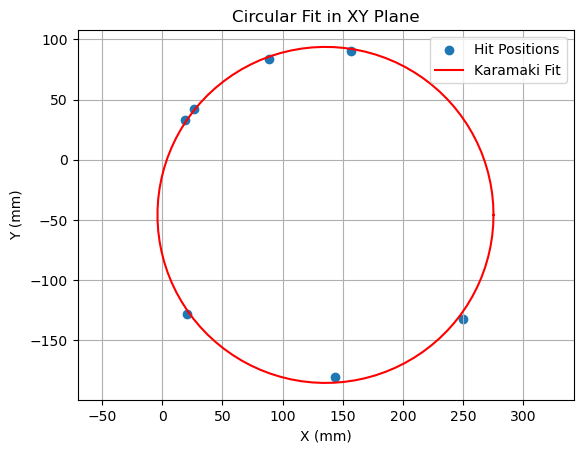

In [ ]:
xc, yc, R_abs = karamaki_fit(x, y)
phi_fit = np.linspace(0, 2 * np.pi, 100)
x_fit = xc + R_abs * np.cos(phi_fit)
y_fit = yc + R_abs * np.sin(phi_fit)

plt.scatter(x, y, label="Hit Positions")
plt.plot(x_fit, y_fit, color="red", label="Karamaki Fit")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title("Circular Fit in XY Plane")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

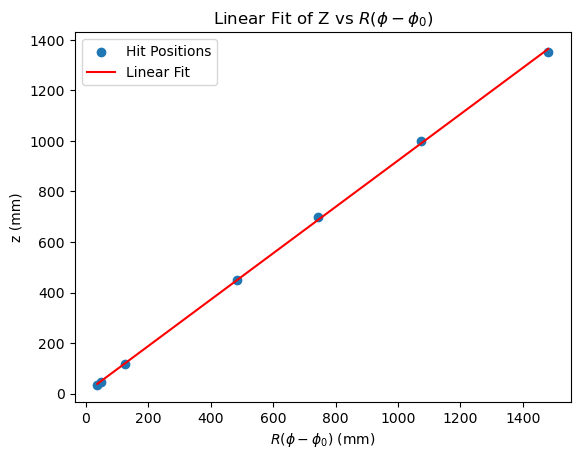

In [ ]:
phi_c = np.unwrap(np.arctan2(y - yc, x - xc))

dphi_mean = np.mean(np.diff(phi_c))

rot_sign = np.sign(dphi_mean)  

R = rot_sign * R_abs

d0 = np.sqrt(xc ** 2 + yc ** 2) - R_abs

phi0 = np.arctan2(-xc, yc)

phi = np.unwrap(np.arctan2(x - xc, -(y - yc)))
phi = phi - 2.0 * np.pi * np.round((phi[0] - phi0) / (2.0 * np.pi))

u = R * (phi - phi0)
A = np.vstack([u, np.ones_like(u)]).T
tanl, z0 = np.linalg.lstsq(A, z, rcond=None)[0]

plt.scatter(u, z, label="Hit Positions")
plt.plot(u, tanl * u + z0, color="red", label="Linear Fit")
plt.xlabel("$R(\phi - \phi_0)$ (mm)")
plt.ylabel("z (mm)")
plt.title("Linear Fit of Z vs $R(\phi - \phi_0)$")
plt.legend()
plt.show()  

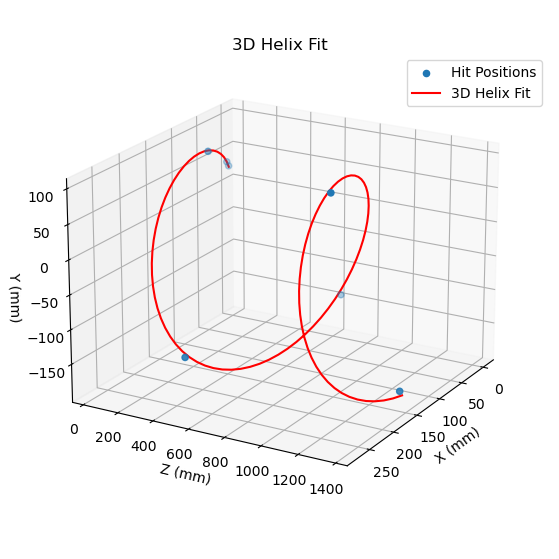

In [ ]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, z, y, label="Hit Positions")

phi_fit = np.linspace(phi[0], phi[-1], 100)

x_fit, y_fit, z_fit = helix(phi_fit, d0, z0, tanl, R, phi0)
ax.plot(x_fit, z_fit, y_fit, color="red", label="3D Helix Fit")

ax.set_xlabel("X (mm)")
ax.set_ylabel("Z (mm)")
ax.set_zlabel("Y (mm)")
ax.set_title("3D Helix Fit", y=0.99)
ax.view_init(elev=20, azim=30)
ax.set_box_aspect(None, zoom=0.9)

ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.92))

plt.show()